In [1]:
#=============================================
# AI SHOCKWAVE INDEX
# Economic Impact Analysis of Major Events
#=============================================

# The 6 events we identified through research

ai_events = {
    "ChatGPT Launch":            "2022-11-30",
    "GPT_4 Release":             "2023-03-14",
    "Nvidia $1T Market Cap":     "2023-05-30",
    "Sam Altman Fired":          "2023-11-17",
    "DeepSeek R1 Launch":        "2025-01-20",
    "Meta $65B Investment":      "2025-01-24",
}

# Companies organized by the categories you built in your research 

companies = {
    "Ai Winners":    ["NVDA", "MSFT", "GOOGL", "META"],
    "Disrupted":     ["CHGG", "DUOL", "UPWK", "FVRR"],
    "Infrastructure": ["AMD", "PLTR", "ORCL", "AMZN"]
}

print('Events loaded:', len(ai_events))
print('Companies loaded:', sum(len(v) for v in companies.values()))

Events loaded: 6
Companies loaded: 12


In [2]:
!pip3 install plotly

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 9.9 MB 3.9 MB/s eta 0:00:01
     |████████████████████████████████| 74 kB 2.8 MB/s eta 0:00:011
     |████████████████████████████████| 444 kB 5.1 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [7]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

def get_event_data(ticker, event_date, window=30):
    date = datetime.strptime(event_date, "%Y-%m-%d")
    start = date - timedelta(days=window)
    end = date + timedelta(days=window)
    
    stock = yf.Ticker(ticker)
    df = stock.history(start=start, end=end)
    df['ticker'] = ticker
    df['event_date'] = date
    df['days_from_event'] = (df.index.tz_localize(None) - date).days
    df['pct_change'] = df['Close'].pct_change() * 100
    
    return df

test = get_event_data("NVDA", "2025-01-20")
print(test[['Close', 'days_from_event', 'pct_change']].head(10))

                                Close  days_from_event  pct_change
Date                                                              
2024-12-23 00:00:00-05:00  139.624252              -28         NaN
2024-12-24 00:00:00-05:00  140.174072              -27    0.393785
2024-12-26 00:00:00-05:00  139.884171              -25   -0.206816
2024-12-27 00:00:00-05:00  136.965118              -24   -2.086764
2024-12-30 00:00:00-05:00  137.444946              -21    0.350329
2024-12-31 00:00:00-05:00  134.246017              -20   -2.327426
2025-01-02 00:00:00-05:00  138.264694              -18    2.993517
2025-01-03 00:00:00-05:00  144.422684              -17    4.453769
2025-01-06 00:00:00-05:00  149.381042              -14    3.433227
2025-01-07 00:00:00-05:00  140.094086              -13   -6.216958


In [8]:
# Pull data for every company across every event
all_data = []

for event_name, event_date in ai_events.items():
    for category, tickers in companies.items():
        for ticker in tickers:
            print(f"Pulling {ticker} for {event_name}...")
            df = get_event_data(ticker, event_date)
            df['event_name'] = event_name
            df['category'] = category
            all_data.append(df)

master_df = pd.concat(all_data)
print(f"\nDone! Total rows of data: {len(master_df)}")

Pulling NVDA for ChatGPT Launch...
Pulling MSFT for ChatGPT Launch...
Pulling GOOGL for ChatGPT Launch...
Pulling META for ChatGPT Launch...
Pulling CHGG for ChatGPT Launch...
Pulling DUOL for ChatGPT Launch...
Pulling UPWK for ChatGPT Launch...
Pulling FVRR for ChatGPT Launch...
Pulling AMD for ChatGPT Launch...
Pulling PLTR for ChatGPT Launch...
Pulling ORCL for ChatGPT Launch...
Pulling AMZN for ChatGPT Launch...
Pulling NVDA for GPT_4 Release...
Pulling MSFT for GPT_4 Release...
Pulling GOOGL for GPT_4 Release...
Pulling META for GPT_4 Release...
Pulling CHGG for GPT_4 Release...
Pulling DUOL for GPT_4 Release...
Pulling UPWK for GPT_4 Release...
Pulling FVRR for GPT_4 Release...
Pulling AMD for GPT_4 Release...
Pulling PLTR for GPT_4 Release...
Pulling ORCL for GPT_4 Release...
Pulling AMZN for GPT_4 Release...
Pulling NVDA for Nvidia $1T Market Cap...
Pulling MSFT for Nvidia $1T Market Cap...
Pulling GOOGL for Nvidia $1T Market Cap...
Pulling META for Nvidia $1T Market Cap...
Pul

In [9]:
print(master_df[['ticker', 'event_name', 'category', 'Close', 'days_from_event', 'pct_change']].head(15))
print("\nEvents covered:", master_df['event_name'].unique())
print("Companies covered:", master_df['ticker'].unique())

                          ticker      event_name    category      Close  \
Date                                                                      
2022-10-31 00:00:00-04:00   NVDA  ChatGPT Launch  Ai Winners  13.479324   
2022-11-01 00:00:00-04:00   NVDA  ChatGPT Launch  Ai Winners  13.525264   
2022-11-02 00:00:00-04:00   NVDA  ChatGPT Launch  Ai Winners  13.201689   
2022-11-03 00:00:00-04:00   NVDA  ChatGPT Launch  Ai Winners  13.403421   
2022-11-04 00:00:00-04:00   NVDA  ChatGPT Launch  Ai Winners  14.137463   
2022-11-07 00:00:00-05:00   NVDA  ChatGPT Launch  Ai Winners  14.282270   
2022-11-08 00:00:00-05:00   NVDA  ChatGPT Launch  Ai Winners  14.582876   
2022-11-09 00:00:00-05:00   NVDA  ChatGPT Launch  Ai Winners  13.757958   
2022-11-10 00:00:00-05:00   NVDA  ChatGPT Launch  Ai Winners  15.729373   
2022-11-11 00:00:00-05:00   NVDA  ChatGPT Launch  Ai Winners  16.305616   
2022-11-14 00:00:00-05:00   NVDA  ChatGPT Launch  Ai Winners  16.273661   
2022-11-15 00:00:00-05:00

In [10]:
def calculate_impact(master_df):
    """
    For each company + event combination,
    calculate the total price impact around the event
    """
    results = []
    
    for event_name in master_df['event_name'].unique():
        for ticker in master_df['ticker'].unique():
            
            subset = master_df[
                (master_df['event_name'] == event_name) & 
                (master_df['ticker'] == ticker)
            ]
            
            before = subset[subset['days_from_event'] < 0]['Close'].mean()
            after = subset[subset['days_from_event'] > 0]['Close'].mean()
            impact = ((after - before) / before) * 100
            
            category = subset['category'].iloc[0]
            
            results.append({
                'event': event_name,
                'ticker': ticker,
                'category': category,
                'avg_before': round(before, 2),
                'avg_after': round(after, 2),
                'impact_pct': round(impact, 2)
            })
    
    return pd.DataFrame(results)

impact_df = calculate_impact(master_df)
print(impact_df.sort_values('impact_pct').head(10))

                   event ticker        category  avg_before  avg_after  \
6         ChatGPT Launch   UPWK       Disrupted       12.82      10.95   
19         GPT_4 Release   FVRR       Disrupted       39.27      34.19   
9         ChatGPT Launch   PLTR  Infrastructure        7.70       6.86   
18         GPT_4 Release   UPWK       Disrupted       11.75      10.64   
52    DeepSeek R1 Launch   CHGG       Disrupted        1.63       1.49   
7         ChatGPT Launch   FVRR       Disrupted       33.62      30.85   
64  Meta $65B Investment   CHGG       Disrupted        1.60       1.48   
60  Meta $65B Investment   NVDA      Ai Winners      139.11     129.39   
68  Meta $65B Investment    AMD  Infrastructure      122.03     113.53   
11        ChatGPT Launch   AMZN  Infrastructure       94.23      88.13   

    impact_pct  
6       -14.57  
19      -12.95  
9       -10.87  
18       -9.48  
52       -8.67  
7        -8.23  
64       -7.53  
60       -6.98  
68       -6.97  
11       -6.47 

In [11]:
print(impact_df.sort_values('impact_pct', ascending=False).head(10))

                    event ticker        category  avg_before  avg_after  \
33  Nvidia $1T Market Cap   PLTR  Infrastructure       10.01      15.11   
69   Meta $65B Investment   PLTR  Infrastructure       73.30     102.01   
24  Nvidia $1T Market Cap   NVDA      Ai Winners       30.24      40.67   
57     DeepSeek R1 Launch   PLTR  Infrastructure       73.74      96.32   
41       Sam Altman Fired   DUOL       Disrupted      169.42     219.81   
17          GPT_4 Release   DUOL       Disrupted      104.89     134.81   
40       Sam Altman Fired   CHGG       Disrupted        8.55      10.39   
42       Sam Altman Fired   UPWK       Disrupted       11.78      14.19   
20          GPT_4 Release    AMD  Infrastructure       80.95      95.76   
65   Meta $65B Investment   DUOL       Disrupted      330.03     390.33   

    impact_pct  
33       50.92  
69       39.16  
24       34.50  
57       30.62  
41       29.75  
17       28.52  
40       21.50  
42       20.47  
20       18.29  
65  

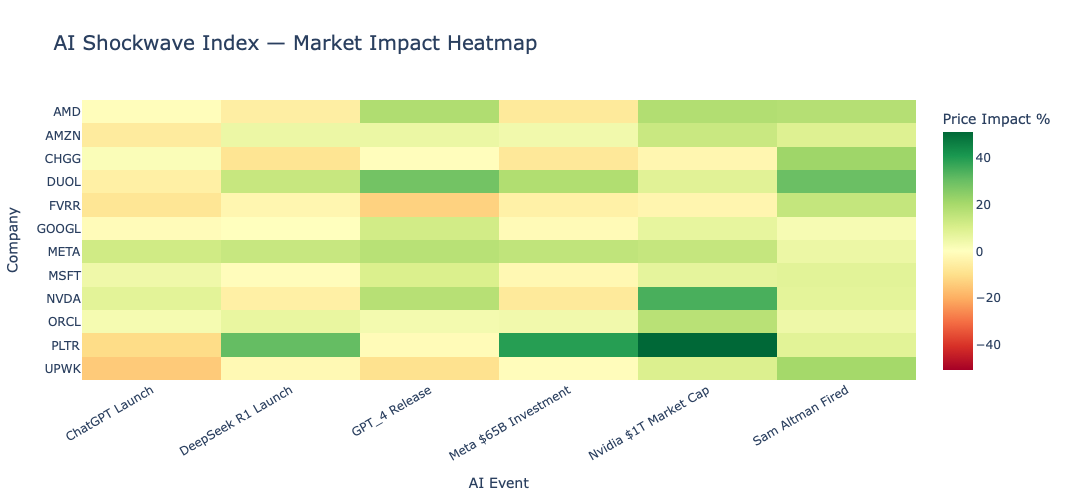

In [12]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Chart 1 — The Impact Heatmap
# Shows every company vs every event in one visual

pivot = impact_df.pivot(index='ticker', columns='event', values='impact_pct')

fig = px.imshow(
    pivot,
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    title='AI Shockwave Index — Market Impact Heatmap',
    labels=dict(color='Price Impact %'),
    aspect='auto'
)

fig.update_layout(
    title_font_size=20,
    xaxis_title='AI Event',
    yaxis_title='Company',
    xaxis_tickangle=-30,
    height=500
)

fig.show()

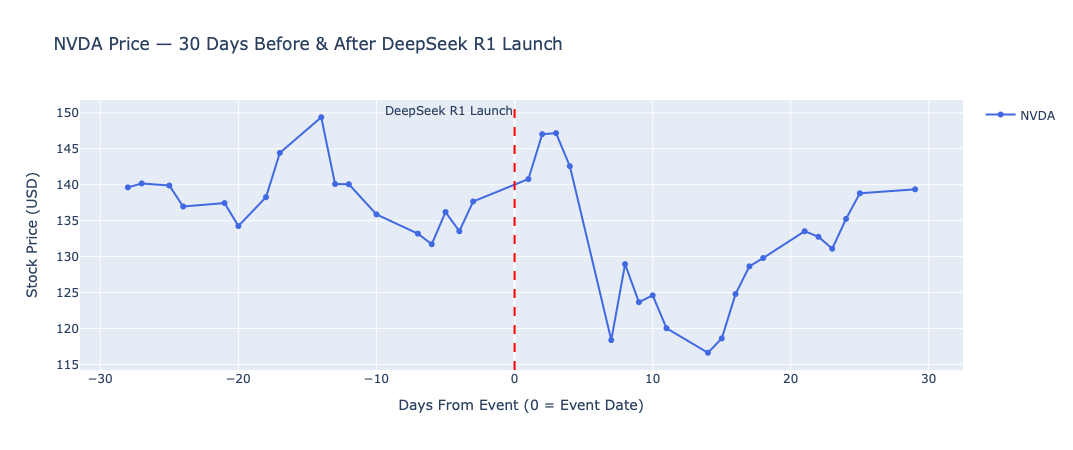

In [13]:
# Chart 2 — Day by Day Price Movement Around Each Event
# Pick one company and see the full story around each event

def plot_event_timeline(ticker, event_name):
    
    subset = master_df[
        (master_df['ticker'] == ticker) & 
        (master_df['event_name'] == event_name)
    ].copy()
    
    fig = go.Figure()
    
    # Price line
    fig.add_trace(go.Scatter(
        x=subset['days_from_event'],
        y=subset['Close'],
        mode='lines+markers',
        name=ticker,
        line=dict(color='royalblue', width=2)
    ))
    
    # Vertical line marking the exact event date
    fig.add_vline(
        x=0,
        line_dash="dash",
        line_color="red",
        annotation_text=event_name,
        annotation_position="top left"
    )
    
    fig.update_layout(
        title=f'{ticker} Price — 30 Days Before & After {event_name}',
        xaxis_title='Days From Event (0 = Event Date)',
        yaxis_title='Stock Price (USD)',
        height=450,
        showlegend=True
    )
    
    fig.show()

# Test it on your most dramatic finding
plot_event_timeline("NVDA", "DeepSeek R1 Launch")


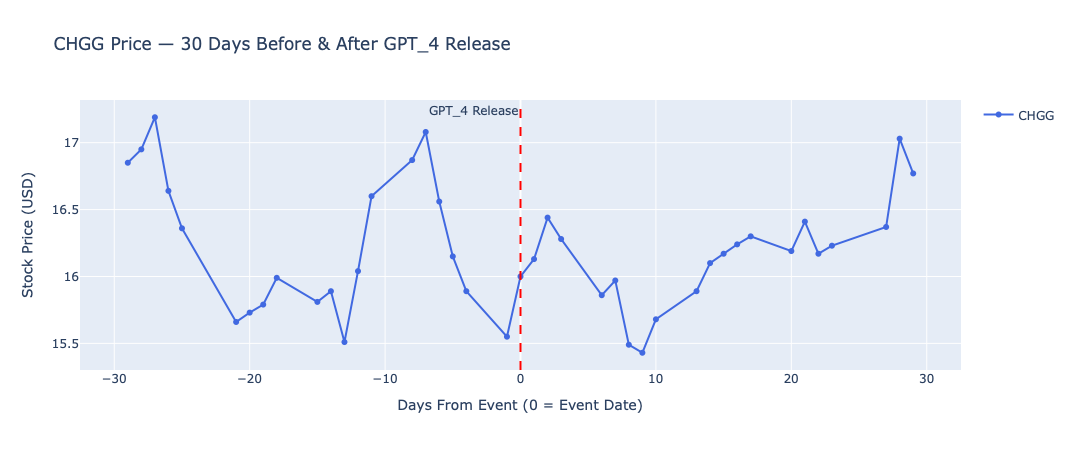

In [14]:
plot_event_timeline("CHGG", "GPT_4 Release")

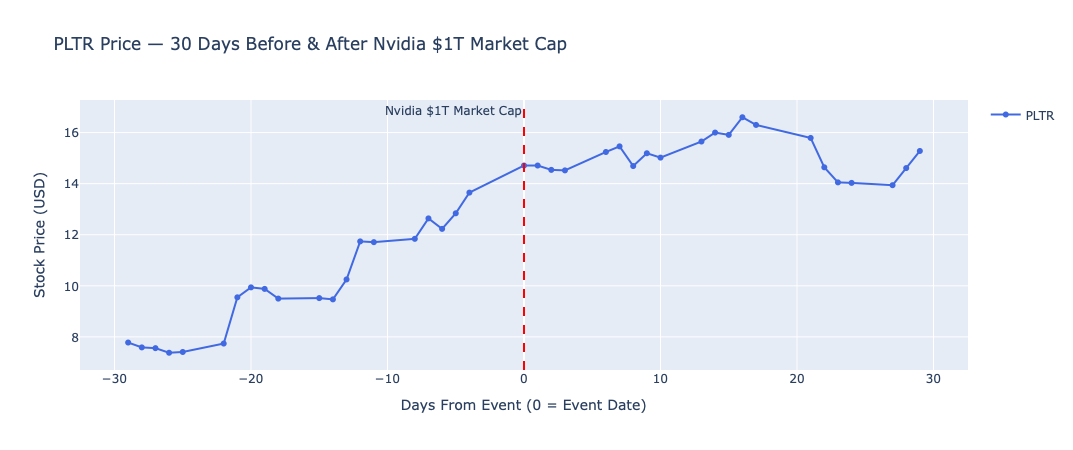

In [15]:
plot_event_timeline("PLTR", "Nvidia $1T Market Cap")

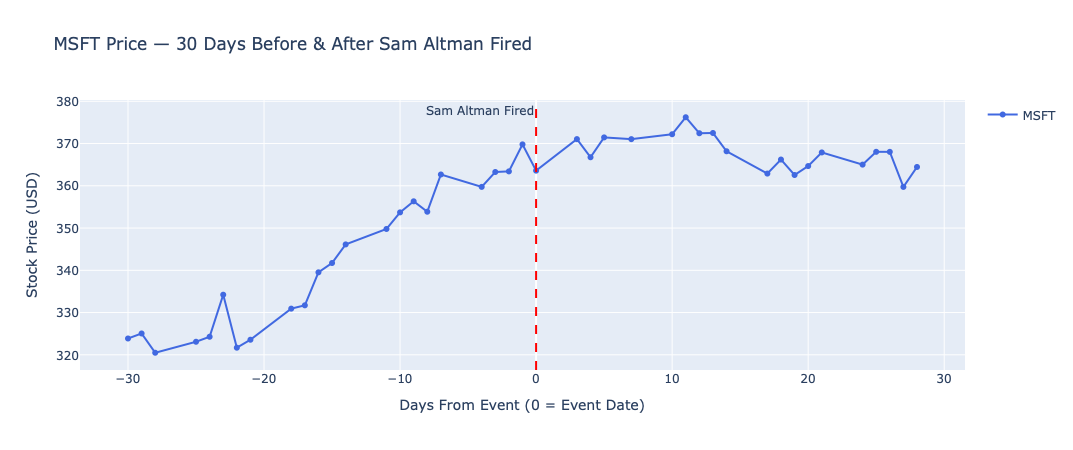

In [16]:
plot_event_timeline("MSFT", "Sam Altman Fired")

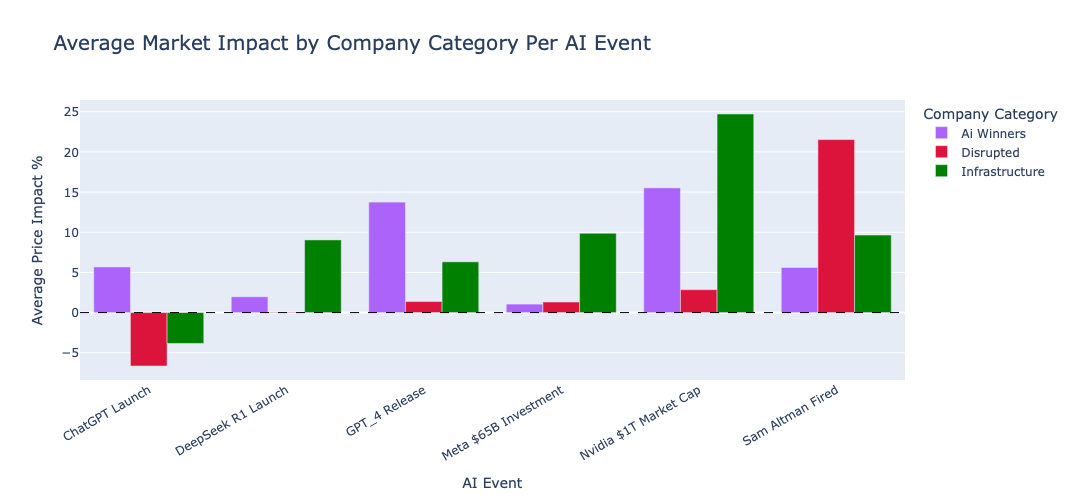

In [17]:
# Chart 3 — Category Impact Comparison
category_impact = impact_df.groupby(
    ['event', 'category'])['impact_pct'].mean().reset_index()

fig = px.bar(
    category_impact,
    x='event',
    y='impact_pct',
    color='category',
    barmode='group',
    title='Average Market Impact by Company Category Per AI Event',
    labels={
        'impact_pct': 'Average Price Impact %',
        'event': 'AI Event',
        'category': 'Company Category'
    },
    color_discrete_map={
        'AI Winners': 'royalblue',
        'Disrupted': 'crimson',
        'Infrastructure': 'green'
    },
    height=500
)

fig.add_hline(
    y=0,
    line_dash='dash',
    line_color='black',
    line_width=1
)

fig.update_layout(
    xaxis_tickangle=-30,
    title_font_size=20
)

fig.show()

In [18]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go

app = Dash(__name__)

# Get unique values for dropdowns
event_list = list(ai_events.keys())
ticker_list = [t for tickers in companies.values() for t in tickers]

app.layout = html.Div([

    # Header
    html.Div([
        html.H1("AI Shockwave Index",
                style={'color': 'white', 'margin': '0',
                       'fontSize': '32px'}),
        html.P("Measuring the Economic Blast Radius of Major AI Events",
               style={'color': '#aaaaaa', 'margin': '5px 0 0 0'})
    ], style={
        'backgroundColor': '#1a1a2e',
        'padding': '30px',
        'marginBottom': '20px'
    }),

    # Main content
    html.Div([

        # Heatmap section
        html.H2("Market Impact Heatmap",
                style={'color': '#333', 'marginBottom': '10px'}),
        html.P("Green = stock gained | Red = stock dropped | Around each AI event",
               style={'color': '#666', 'marginBottom': '15px'}),
        dcc.Graph(
            id='heatmap',
            figure=px.imshow(
                impact_df.pivot(
                    index='ticker',
                    columns='event',
                    values='impact_pct'
                ),
                color_continuous_scale='RdYlGn',
                color_continuous_midpoint=0,
                labels=dict(color='Impact %'),
                aspect='auto',
                height=400
            )
        ),

        html.Hr(style={'margin': '30px 0'}),

        # Event Timeline section
        html.H2("Event Impact Timeline",
                style={'color': '#333', 'marginBottom': '10px'}),
        html.P("Select a company and event to see day-by-day price movement",
               style={'color': '#666', 'marginBottom': '15px'}),

        html.Div([
            html.Div([
                html.Label("Select Company:",
                           style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='ticker-dropdown',
                    options=[{'label': t, 'value': t}
                             for t in ticker_list],
                    value='NVDA',
                    clearable=False
                )
            ], style={'width': '45%', 'display': 'inline-block',
                      'marginRight': '5%'}),

            html.Div([
                html.Label("Select AI Event:",
                           style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='event-dropdown',
                    options=[{'label': e, 'value': e}
                             for e in event_list],
                    value='DeepSeek R1 Launch',
                    clearable=False
                )
            ], style={'width': '45%', 'display': 'inline-block'})
        ], style={'marginBottom': '15px'}),

        dcc.Graph(id='timeline-chart'),

        html.Hr(style={'margin': '30px 0'}),

        # Category comparison section
        html.H2("Category Impact Comparison",
                style={'color': '#333', 'marginBottom': '10px'}),
        html.P("How each company category responded across all AI events",
               style={'color': '#666', 'marginBottom': '15px'}),
        dcc.Graph(
            id='category-chart',
            figure=px.bar(
                impact_df.groupby(
                    ['event', 'category'])['impact_pct'].mean().reset_index(),
                x='event',
                y='impact_pct',
                color='category',
                barmode='group',
                labels={
                    'impact_pct': 'Avg Price Impact %',
                    'event': 'AI Event',
                    'category': 'Category'
                },
                color_discrete_map={
                    'AI Winners': 'royalblue',
                    'Disrupted': 'crimson',
                    'Infrastructure': 'green'
                },
                height=450
            )
        ),

    ], style={
        'maxWidth': '1200px',
        'margin': '0 auto',
        'padding': '0 20px'
    }),

    # Footer
    html.Div([
        html.P("Built by Arbab Jabbar | Business Economics | Data: Yahoo Finance",
               style={'color': '#aaaaaa', 'textAlign': 'center',
                      'margin': '0'})
    ], style={
        'backgroundColor': '#1a1a2e',
        'padding': '20px',
        'marginTop': '40px'
    })

])

# Callback — updates timeline when dropdowns change
@app.callback(
    Output('timeline-chart', 'figure'),
    Input('ticker-dropdown', 'value'),
    Input('event-dropdown', 'value')
)
def update_timeline(ticker, event_name):
    subset = master_df[
        (master_df['ticker'] == ticker) &
        (master_df['event_name'] == event_name)
    ].copy()

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=subset['days_from_event'],
        y=subset['Close'],
        mode='lines+markers',
        name=ticker,
        line=dict(color='royalblue', width=2)
    ))

    fig.add_vline(
        x=0,
        line_dash="dash",
        line_color="red",
        annotation_text=f"{event_name}",
        annotation_position="top left"
    )

    fig.update_layout(
        title=f'{ticker} — 30 Days Before & After {event_name}',
        xaxis_title='Days From Event (0 = Event Date)',
        yaxis_title='Stock Price (USD)',
        height=450
    )

    return fig

if __name__ == '__main__':
    app.run(debug=True, port=8051)

ModuleNotFoundError: No module named 'dash'

In [19]:
!pip3 install dash

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.2 MB 17.3 MB/s eta 0:00:01
     |████████████████████████████████| 103 kB 3.2 MB/s eta 0:00:01
     |████████████████████████████████| 226 kB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 98 kB 7.3 MB/s eta 0:00:011
     |████████████████████████████████| 134 kB 14.5 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [20]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go

app = Dash(__name__)

# Get unique values for dropdowns
event_list = list(ai_events.keys())
ticker_list = [t for tickers in companies.values() for t in tickers]

app.layout = html.Div([

    # Header
    html.Div([
        html.H1("AI Shockwave Index",
                style={'color': 'white', 'margin': '0',
                       'fontSize': '32px'}),
        html.P("Measuring the Economic Blast Radius of Major AI Events",
               style={'color': '#aaaaaa', 'margin': '5px 0 0 0'})
    ], style={
        'backgroundColor': '#1a1a2e',
        'padding': '30px',
        'marginBottom': '20px'
    }),

    # Main content
    html.Div([

        # Heatmap section
        html.H2("Market Impact Heatmap",
                style={'color': '#333', 'marginBottom': '10px'}),
        html.P("Green = stock gained | Red = stock dropped | Around each AI event",
               style={'color': '#666', 'marginBottom': '15px'}),
        dcc.Graph(
            id='heatmap',
            figure=px.imshow(
                impact_df.pivot(
                    index='ticker',
                    columns='event',
                    values='impact_pct'
                ),
                color_continuous_scale='RdYlGn',
                color_continuous_midpoint=0,
                labels=dict(color='Impact %'),
                aspect='auto',
                height=400
            )
        ),

        html.Hr(style={'margin': '30px 0'}),

        # Event Timeline section
        html.H2("Event Impact Timeline",
                style={'color': '#333', 'marginBottom': '10px'}),
        html.P("Select a company and event to see day-by-day price movement",
               style={'color': '#666', 'marginBottom': '15px'}),

        html.Div([
            html.Div([
                html.Label("Select Company:",
                           style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='ticker-dropdown',
                    options=[{'label': t, 'value': t}
                             for t in ticker_list],
                    value='NVDA',
                    clearable=False
                )
            ], style={'width': '45%', 'display': 'inline-block',
                      'marginRight': '5%'}),

            html.Div([
                html.Label("Select AI Event:",
                           style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='event-dropdown',
                    options=[{'label': e, 'value': e}
                             for e in event_list],
                    value='DeepSeek R1 Launch',
                    clearable=False
                )
            ], style={'width': '45%', 'display': 'inline-block'})
        ], style={'marginBottom': '15px'}),

        dcc.Graph(id='timeline-chart'),

        html.Hr(style={'margin': '30px 0'}),

        # Category comparison section
        html.H2("Category Impact Comparison",
                style={'color': '#333', 'marginBottom': '10px'}),
        html.P("How each company category responded across all AI events",
               style={'color': '#666', 'marginBottom': '15px'}),
        dcc.Graph(
            id='category-chart',
            figure=px.bar(
                impact_df.groupby(
                    ['event', 'category'])['impact_pct'].mean().reset_index(),
                x='event',
                y='impact_pct',
                color='category',
                barmode='group',
                labels={
                    'impact_pct': 'Avg Price Impact %',
                    'event': 'AI Event',
                    'category': 'Category'
                },
                color_discrete_map={
                    'AI Winners': 'royalblue',
                    'Disrupted': 'crimson',
                    'Infrastructure': 'green'
                },
                height=450
            )
        ),

    ], style={
        'maxWidth': '1200px',
        'margin': '0 auto',
        'padding': '0 20px'
    }),

    # Footer
    html.Div([
        html.P("Built by Arbab Jabbar | Business Economics | Data: Yahoo Finance",
               style={'color': '#aaaaaa', 'textAlign': 'center',
                      'margin': '0'})
    ], style={
        'backgroundColor': '#1a1a2e',
        'padding': '20px',
        'marginTop': '40px'
    })

])

# Callback — updates timeline when dropdowns change
@app.callback(
    Output('timeline-chart', 'figure'),
    Input('ticker-dropdown', 'value'),
    Input('event-dropdown', 'value')
)
def update_timeline(ticker, event_name):
    subset = master_df[
        (master_df['ticker'] == ticker) &
        (master_df['event_name'] == event_name)
    ].copy()

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=subset['days_from_event'],
        y=subset['Close'],
        mode='lines+markers',
        name=ticker,
        line=dict(color='royalblue', width=2)
    ))

    fig.add_vline(
        x=0,
        line_dash="dash",
        line_color="red",
        annotation_text=f"{event_name}",
        annotation_position="top left"
    )

    fig.update_layout(
        title=f'{ticker} — 30 Days Before & After {event_name}',
        xaxis_title='Days From Event (0 = Event Date)',
        yaxis_title='Stock Price (USD)',
        height=450
    )

    return fig

if __name__ == '__main__':
    app.run(debug=True, port=8051)

ModuleNotFoundError: No module named 'dash'

In [21]:
import sys
!{sys.prefix}/bin/pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 5.8 MB/s  0:00:01m 5.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [dash]━━━━━━ 1/2 [dash]


In [22]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go

app = Dash(__name__)

# Get unique values for dropdowns
event_list = list(ai_events.keys())
ticker_list = [t for tickers in companies.values() for t in tickers]

app.layout = html.Div([

    # Header
    html.Div([
        html.H1("AI Shockwave Index",
                style={'color': 'white', 'margin': '0',
                       'fontSize': '32px'}),
        html.P("Measuring the Economic Blast Radius of Major AI Events",
               style={'color': '#aaaaaa', 'margin': '5px 0 0 0'})
    ], style={
        'backgroundColor': '#1a1a2e',
        'padding': '30px',
        'marginBottom': '20px'
    }),

    # Main content
    html.Div([

        # Heatmap section
        html.H2("Market Impact Heatmap",
                style={'color': '#333', 'marginBottom': '10px'}),
        html.P("Green = stock gained | Red = stock dropped | Around each AI event",
               style={'color': '#666', 'marginBottom': '15px'}),
        dcc.Graph(
            id='heatmap',
            figure=px.imshow(
                impact_df.pivot(
                    index='ticker',
                    columns='event',
                    values='impact_pct'
                ),
                color_continuous_scale='RdYlGn',
                color_continuous_midpoint=0,
                labels=dict(color='Impact %'),
                aspect='auto',
                height=400
            )
        ),

        html.Hr(style={'margin': '30px 0'}),

        # Event Timeline section
        html.H2("Event Impact Timeline",
                style={'color': '#333', 'marginBottom': '10px'}),
        html.P("Select a company and event to see day-by-day price movement",
               style={'color': '#666', 'marginBottom': '15px'}),

        html.Div([
            html.Div([
                html.Label("Select Company:",
                           style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='ticker-dropdown',
                    options=[{'label': t, 'value': t}
                             for t in ticker_list],
                    value='NVDA',
                    clearable=False
                )
            ], style={'width': '45%', 'display': 'inline-block',
                      'marginRight': '5%'}),

            html.Div([
                html.Label("Select AI Event:",
                           style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='event-dropdown',
                    options=[{'label': e, 'value': e}
                             for e in event_list],
                    value='DeepSeek R1 Launch',
                    clearable=False
                )
            ], style={'width': '45%', 'display': 'inline-block'})
        ], style={'marginBottom': '15px'}),

        dcc.Graph(id='timeline-chart'),

        html.Hr(style={'margin': '30px 0'}),

        # Category comparison section
        html.H2("Category Impact Comparison",
                style={'color': '#333', 'marginBottom': '10px'}),
        html.P("How each company category responded across all AI events",
               style={'color': '#666', 'marginBottom': '15px'}),
        dcc.Graph(
            id='category-chart',
            figure=px.bar(
                impact_df.groupby(
                    ['event', 'category'])['impact_pct'].mean().reset_index(),
                x='event',
                y='impact_pct',
                color='category',
                barmode='group',
                labels={
                    'impact_pct': 'Avg Price Impact %',
                    'event': 'AI Event',
                    'category': 'Category'
                },
                color_discrete_map={
                    'AI Winners': 'royalblue',
                    'Disrupted': 'crimson',
                    'Infrastructure': 'green'
                },
                height=450
            )
        ),

    ], style={
        'maxWidth': '1200px',
        'margin': '0 auto',
        'padding': '0 20px'
    }),

    # Footer
    html.Div([
        html.P("Built by Arbab Jabbar | Business Economics | Data: Yahoo Finance",
               style={'color': '#aaaaaa', 'textAlign': 'center',
                      'margin': '0'})
    ], style={
        'backgroundColor': '#1a1a2e',
        'padding': '20px',
        'marginTop': '40px'
    })

])

# Callback — updates timeline when dropdowns change
@app.callback(
    Output('timeline-chart', 'figure'),
    Input('ticker-dropdown', 'value'),
    Input('event-dropdown', 'value')
)
def update_timeline(ticker, event_name):
    subset = master_df[
        (master_df['ticker'] == ticker) &
        (master_df['event_name'] == event_name)
    ].copy()

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=subset['days_from_event'],
        y=subset['Close'],
        mode='lines+markers',
        name=ticker,
        line=dict(color='royalblue', width=2)
    ))

    fig.add_vline(
        x=0,
        line_dash="dash",
        line_color="red",
        annotation_text=f"{event_name}",
        annotation_position="top left"
    )

    fig.update_layout(
        title=f'{ticker} — 30 Days Before & After {event_name}',
        xaxis_title='Days From Event (0 = Event Date)',
        yaxis_title='Stock Price (USD)',
        height=450
    )

    return fig

if __name__ == '__main__':
    app.run(debug=True, port=8051)

In [23]:
requirements = """yfinance
pandas
plotly
dash
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created!")

requirements.txt created!
